##  Data Understanding & Cleaning


### Data Loading & Initial Exploration

In [1]:
# Import Libraries
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 50)

In [2]:
# Load Datasets
titles = pd.read_csv('titles.csv')
credits = pd.read_csv('credits.csv')

print(f"titles.csv  -> {titles.shape[0]} rows, {titles.shape[1]} columns")
print(f"credits.csv -> {credits.shape[0]} rows, {credits.shape[1]} columns")

titles.csv  -> 9871 rows, 15 columns
credits.csv -> 124235 rows, 5 columns


In [3]:
# First 10 rows
titles.head(10)

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6
5,tm160494,Stagecoach,MOVIE,A group of people traveling on a stagecoach fi...,1939,NaN,96,"['western', 'drama']",['US'],NaN,tt0031971,7.8,48149.0,11.786,7.7
6,tm87233,It's a Wonderful Life,MOVIE,A holiday favourite for generations... George...,1946,PG,130,"['drama', 'family', 'fantasy', 'romance', 'com...",['US'],NaN,tt0038650,8.6,444243.0,26.495,8.3
7,tm19424,Detour,MOVIE,"The life of Al Roberts, a pianist in a New Yor...",1945,NaN,66,"['thriller', 'drama', 'crime']",['US'],NaN,tt0037638,7.3,17233.0,7.757,7.2
8,tm116781,My Man Godfrey,MOVIE,"Fifth Avenue socialite Irene Bullock needs a ""...",1936,NaN,95,"['comedy', 'romance', 'drama']",['US'],NaN,tt0028010,8.0,23532.0,8.633,7.6
9,tm112005,Marihuana,MOVIE,A young girl named Burma attends a beach party...,1936,NaN,57,"['crime', 'drama']",['US'],NaN,tt0026683,4.0,864.0,3.748,3.6


In [4]:
titles.info()

<class 'pandas.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9871 non-null   str    
 1   title                 9871 non-null   str    
 2   type                  9871 non-null   str    
 3   description           9752 non-null   str    
 4   release_year          9871 non-null   int64  
 5   age_certification     3384 non-null   str    
 6   runtime               9871 non-null   int64  
 7   genres                9871 non-null   str    
 8   production_countries  9871 non-null   str    
 9   seasons               1357 non-null   float64
 10  imdb_id               9204 non-null   str    
 11  imdb_score            8850 non-null   float64
 12  imdb_votes            8840 non-null   float64
 13  tmdb_popularity       9324 non-null   float64
 14  tmdb_score            7789 non-null   float64
dtypes: float64(5), int64(2), str(8)


In [5]:
titles.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,9871,9868,tm89134,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,9871,9737,The Lost World,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,9871,2,MOVIE,8514,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,9752,9734,No overview found.,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,9871.0,NaN,NaN,NaN,2001.327221,25.810071,1912.0,1995.5,2014.0,2018.0,2022.0
age_certification,3384,11,R,1249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
runtime,9871.0,NaN,NaN,NaN,85.973052,33.512466,1.0,65.0,89.0,102.0,549.0
genres,9871,2028,['drama'],908,NaN,NaN,NaN,NaN,NaN,NaN,NaN
production_countries,9871,497,['US'],4810,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seasons,1357.0,NaN,NaN,NaN,2.791452,4.148958,1.0,1.0,1.0,3.0,51.0


### Data Cleaning

In [6]:
# --- Check missing values ---
missing = titles.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(titles) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})[missing > 0]

,missing_count,missing_pct
seasons,8514,86.25
age_certification,6487,65.72
tmdb_score,2082,21.09
imdb_votes,1031,10.44
imdb_score,1021,10.34
imdb_id,667,6.76
tmdb_popularity,547,5.54
description,119,1.21


In [7]:
# --- Remove exact duplicate rows ---
dup_count = titles.duplicated().sum()
print(f"Exact duplicate rows: {dup_count}")
titles = titles.drop_duplicates().reset_index(drop=True)
print(f"Shape after dropping duplicates: {titles.shape}")

Exact duplicate rows: 3
Shape after dropping duplicates: (9868, 15)


In [8]:
# --- Parse stringified list columns into real Python lists ---
def parse_list(val):
    try:
        parsed = ast.literal_eval(val)
        return parsed if isinstance(parsed, list) else []
    except (ValueError, SyntaxError):
        return []

titles['genres'] = titles['genres'].apply(parse_list)
titles['production_countries'] = titles['production_countries'].apply(parse_list)

titles[['title', 'genres', 'production_countries']].head()

,title,genres,production_countries
0,The Three Stooges,"[comedy, family, animation, action, fantasy, h...",[US]
1,The General,"[action, drama, war, western, comedy, european]",[US]
2,The Best Years of Our Lives,"[romance, war, drama]",[US]
3,His Girl Friday,"[comedy, drama, romance]",[US]
4,In a Lonely Place,"[thriller, drama, romance]",[US]


In [9]:
# --- Standardize text formatting in categorical columns ---
titles['title'] = titles['title'].str.strip()
titles['type'] = titles['type'].str.strip().str.upper()
titles['genres'] = titles['genres'].apply(lambda lst: [g.strip().title() for g in lst])
titles['production_countries'] = titles['production_countries'].apply(
    lambda lst: [c.strip().upper() for c in lst])

print(titles['type'].value_counts())

type
MOVIE    8511
SHOW     1357
Name: count, dtype: int64


In [10]:
# --- Handle remaining missing values ---
# age_certification: missing means genuinely unrated/unknown -> explicit category, not the mode
titles['age_certification'] = titles['age_certification'].fillna('Not Rated')

# description: a handful missing -> fill with placeholder (not used for numeric analysis)
titles['description'] = titles['description'].fillna('No description available')

# seasons: NaN for Movies is structural (not applicable), not missing data -> leave as NaN
# (Movies simply do not have seasons; imputing would be misleading)

# imdb / tmdb score, votes, popularity: leave as NaN for now - these are analyzed with dropna()
# per-plot rather than imputed, to avoid biasing rating distributions with fabricated values

print(titles.isnull().sum())

id                         0
title                      0
type                       0
description                0
release_year               0
age_certification          0
runtime                    0
genres                     0
production_countries       0
seasons                 8511
imdb_id                  667
imdb_score              1021
imdb_votes              1031
tmdb_popularity          547
tmdb_score              2080
dtype: int64


In [11]:
# --- Convert release_year into a datetime-like Period for potential time-based ops ---
titles['release_date'] = pd.to_datetime(titles['release_year'].astype(str) + '-01-01')

titles.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,release_date
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"[Comedy, Family, Animation, Action, Fantasy, H...",[US],26.0,tt0850645,8.6,1092.0,15.424,7.6,1934-01-01
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,Not Rated,78,"[Action, Drama, War, Western, Comedy, European]",[US],NaN,tt0017925,8.2,89766.0,8.647,8.0,1926-01-01
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,Not Rated,171,"[Romance, War, Drama]",[US],NaN,tt0036868,8.1,63026.0,8.435,7.8,1946-01-01
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,Not Rated,92,"[Comedy, Drama, Romance]",[US],NaN,tt0032599,7.8,57835.0,11.270,7.4,1940-01-01
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,Not Rated,94,"[Thriller, Drama, Romance]",[US],NaN,tt0042593,7.9,30924.0,8.273,7.6,1950-01-01


In [12]:
df = titles.copy()  # cleaned working dataframe used throughout the rest of the notebook
print(f"Final cleaned shape: {df.shape}")

Final cleaned shape: (9868, 16)


##  Univariate Analysis

### Content Types

type
MOVIE    8511
SHOW     1357
Name: count, dtype: int64
type
MOVIE    86.2
SHOW     13.8
Name: count, dtype: float64


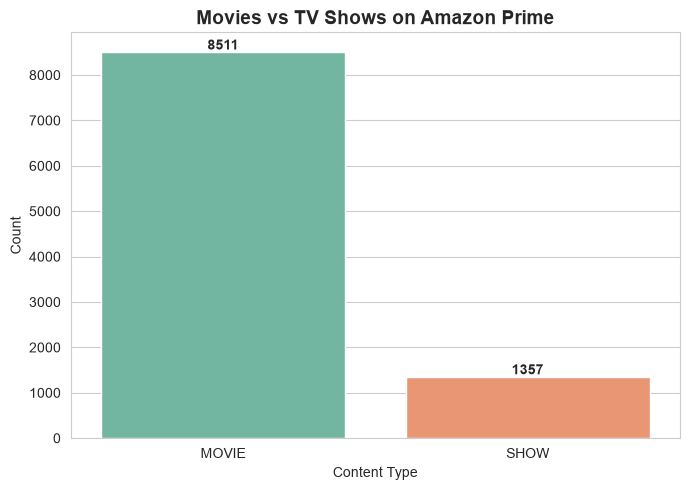

In [ ]:
# --- Content Distribution Across The Platform ---
type_counts = df['type'].value_counts()
print(type_counts)
print((type_counts / len(df) * 100).round(1))

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=type_counts.index, y=type_counts.values, hue=type_counts.index,
            palette='Set2', legend=False, ax=ax)
ax.set_title('Movies vs TV Shows on Amazon Prime', fontsize=14, fontweight='bold')
ax.set_xlabel('Content Type')
ax.set_ylabel('Count')
for i, v in enumerate(type_counts.values):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### Release Year

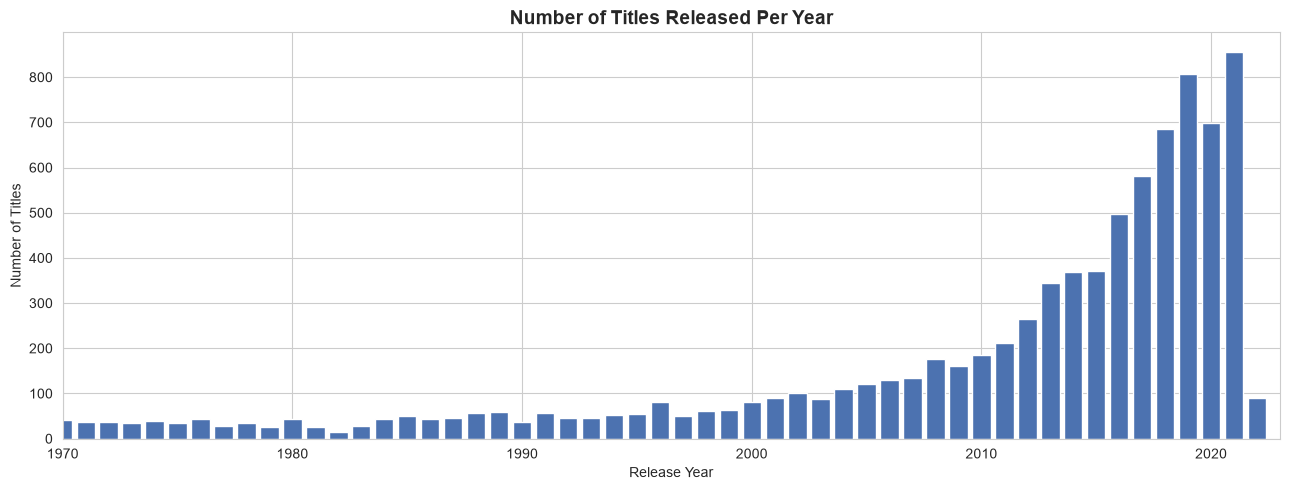

Earliest release year: 1912
Most common release year: 2021 (856 titles)


In [14]:
year_counts = df['release_year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(year_counts.index, year_counts.values, color='#4C72B0', width=0.8)
ax.set_title('Number of Titles Released Per Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Release Year')
ax.set_ylabel('Number of Titles')
ax.set_xlim(1970, 2023)
plt.tight_layout()
plt.show()

print("Earliest release year:", df['release_year'].min())
print("Most common release year:", year_counts.idxmax(), f"({year_counts.max()} titles)")

### Genre Distribution

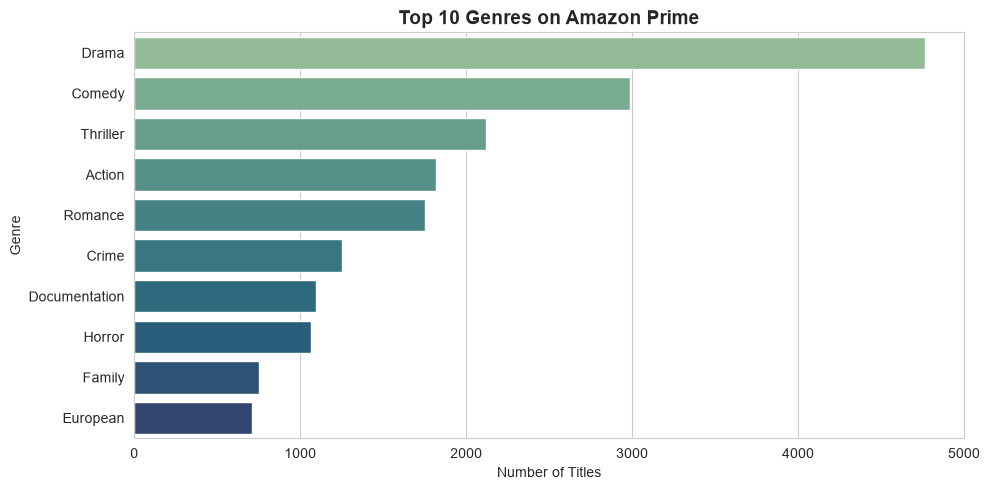

genres
Drama            4762
Comedy           2987
Thriller         2119
Action           1820
Romance          1751
Crime            1250
Documentation    1096
Horror           1065
Family            751
European          712
Name: count, dtype: int64

In [15]:
genre_exploded = df.explode('genres').reset_index(drop=True)
genre_counts = genre_exploded['genres'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=genre_counts.values, y=genre_counts.index, hue=genre_counts.index,
            palette='crest', legend=False, ax=ax)
ax.set_title('Top 10 Genres on Amazon Prime', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Titles')
ax.set_ylabel('Genre')
plt.tight_layout()
plt.show()

genre_counts

### Ratings 

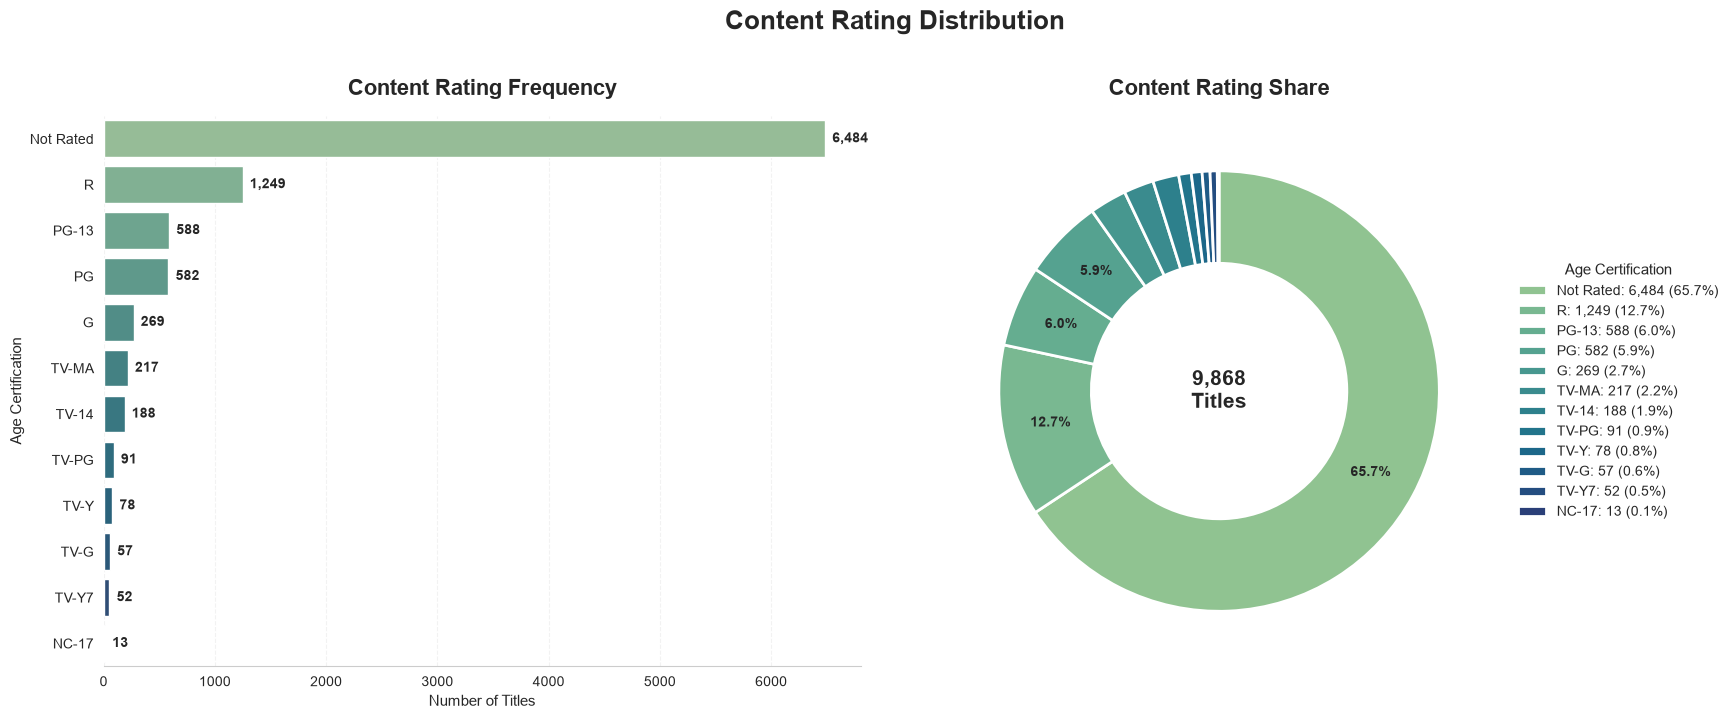

age_certification
Not Rated    6484
R            1249
PG-13         588
PG            582
G             269
TV-MA         217
TV-14         188
TV-PG          91
TV-Y           78
TV-G           57
TV-Y7          52
NC-17          13
Name: count, dtype: int64

In [21]:
rating_counts = df['age_certification'].value_counts()

# Clean modern palette
colors = sns.color_palette("crest", len(rating_counts))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# =========================================================
# 1. BAR CHART - CONTENT RATING FREQUENCY
# =========================================================

bars = sns.barplot(
    x=rating_counts.values,
    y=rating_counts.index,
    hue=rating_counts.index,
    palette=colors,
    legend=False,
    ax=axes[0]
)

axes[0].set_title(
    'Content Rating Frequency',
    fontsize=16,
    fontweight='bold',
    pad=15
)

axes[0].set_xlabel('Number of Titles', fontsize=11)
axes[0].set_ylabel('Age Certification', fontsize=11)

# Add values to bars
for bar in bars.patches:
    axes[0].text(
        bar.get_width() + rating_counts.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width()):,}',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

# Grid
axes[0].grid(
    axis='x',
    linestyle='--',
    alpha=0.25
)

axes[0].set_axisbelow(True)

# Remove unnecessary borders
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['left'].set_visible(False)


# =========================================================
# 2. DONUT CHART - CONTENT RATING SHARE
# =========================================================

def show_percentage(pct):
    # Only display percentage for slices >= 3%
    return f'{pct:.1f}%' if pct >= 3 else ''

wedges, _, autotexts = axes[1].pie(
    rating_counts.values,
    labels=None,                  # Remove overlapping labels
    autopct=show_percentage,
    colors=colors,
    startangle=90,
    counterclock=False,
    wedgeprops={
        'width': 0.42,
        'edgecolor': 'white',
        'linewidth': 2
    },
    pctdistance=0.78,
    textprops={
        'fontsize': 10,
        'fontweight': 'bold'
    }
)

axes[1].set_title(
    'Content Rating Share',
    fontsize=16,
    fontweight='bold',
    pad=15
)

# Center text
axes[1].text(
    0,
    0,
    f'{rating_counts.sum():,}\nTitles',
    ha='center',
    va='center',
    fontsize=15,
    fontweight='bold'
)


# =========================================================
# LEGEND
# =========================================================

legend_labels = [
    f'{rating}: {count:,} ({count / rating_counts.sum() * 100:.1f}%)'
    for rating, count in rating_counts.items()
]

axes[1].legend(
    wedges,
    legend_labels,
    title='Age Certification',
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=10,
    title_fontsize=11
)


# =========================================================
# OVERALL TITLE
# =========================================================

fig.suptitle(
    'Content Rating Distribution',
    fontsize=19,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()


# Display counts
rating_counts

## Bivariate Analysis

### Content Type by Rating

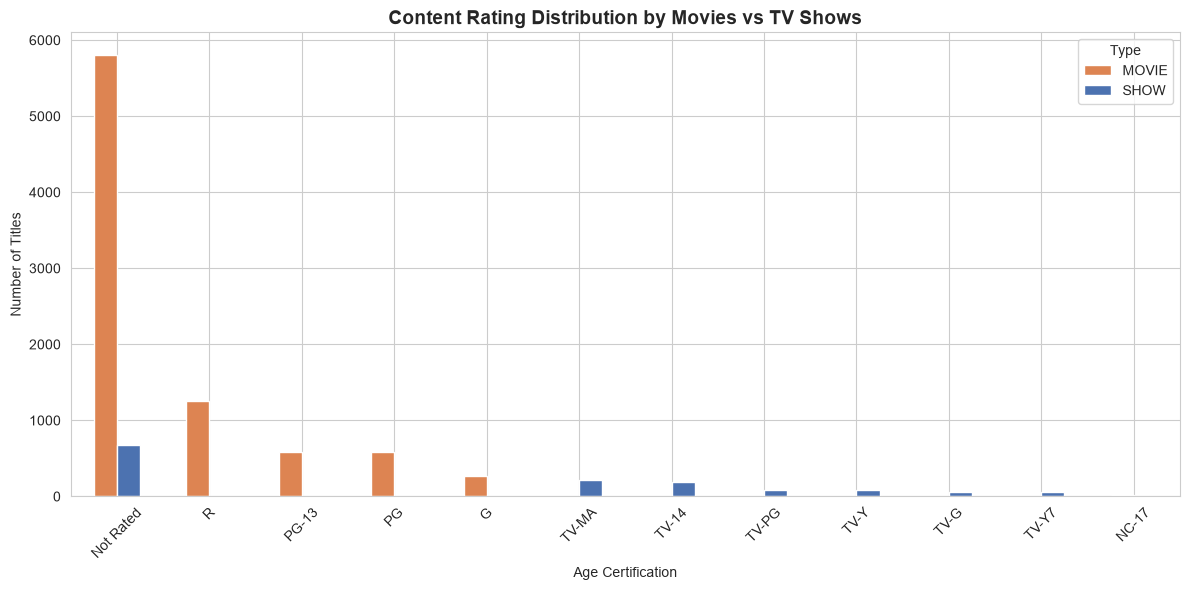

In [ ]:
rating_type_ct = pd.crosstab(df['age_certification'], df['type'])
rating_type_ct = rating_type_ct.loc[rating_type_ct.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(12, 6))
rating_type_ct.plot(kind='bar', ax=ax, color=['#DD8452', '#4C72B0'])
ax.set_title('Content Rating Distribution by Movies vs TV Shows', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Certification')
ax.set_ylabel('Number of Titles')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Type')
plt.tight_layout()
plt.show()

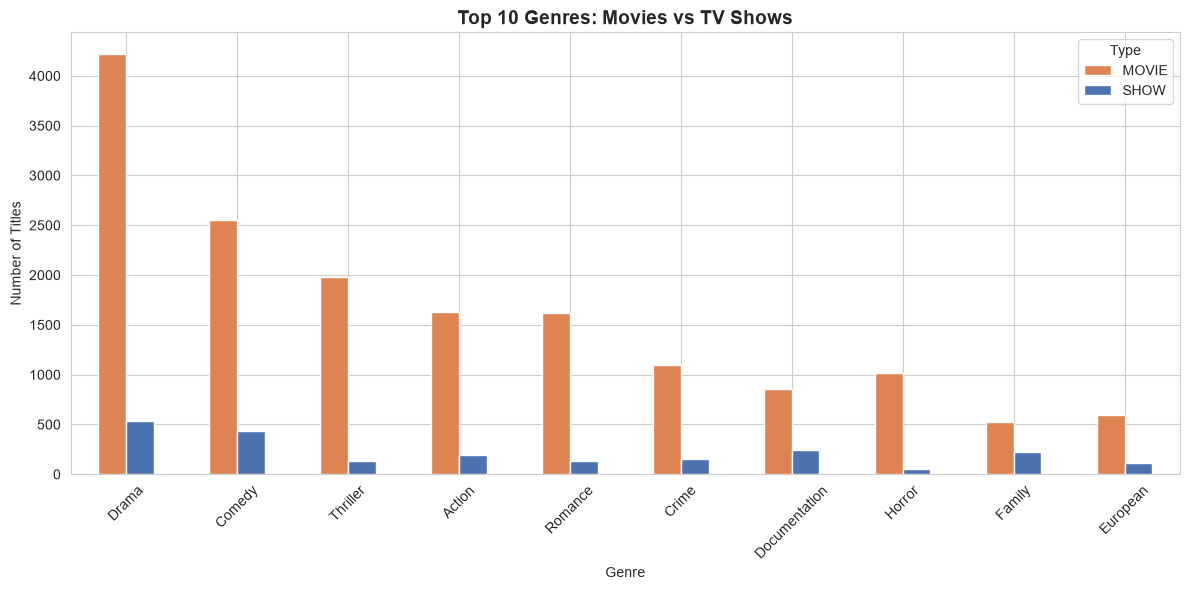

type,MOVIE,SHOW
genres,,
Family,70.4,29.6
Documentation,78.1,21.9
European,83.7,16.3
Comedy,85.6,14.4
Crime,87.6,12.4
Drama,88.7,11.3
Action,89.6,10.4
Romance,92.5,7.5
Thriller,93.7,6.3


In [23]:
genre_type = df.explode('genres').reset_index(drop=True)
genre_type_ct = pd.crosstab(genre_type['genres'], genre_type['type'])
top_genres_list = genre_counts.index  # top 10 genres from Task 5
genre_type_top = genre_type_ct.loc[top_genres_list]

fig, ax = plt.subplots(figsize=(12, 6))
genre_type_top.plot(kind='bar', ax=ax, color=['#DD8452', '#4C72B0'])
ax.set_title('Top 10 Genres: Movies vs TV Shows', fontsize=14, fontweight='bold')
ax.set_xlabel('Genre')
ax.set_ylabel('Number of Titles')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Type')
plt.tight_layout()
plt.show()

# Which genres are proportionally more TV-Show-heavy?
genre_type_pct = (genre_type_ct.div(genre_type_ct.sum(axis=1), axis=0) * 100).loc[top_genres_list]
genre_type_pct.round(1).sort_values('SHOW', ascending=False)

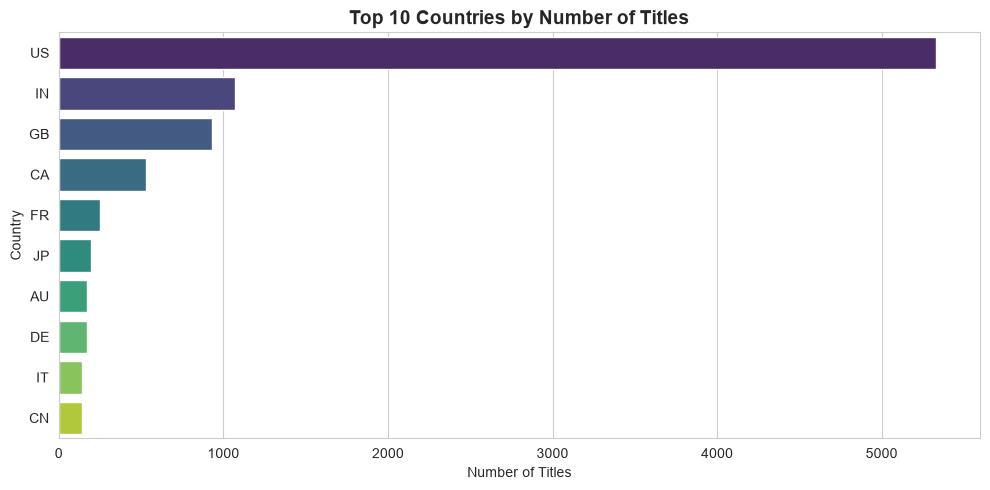

production_countries
US    5331
IN    1072
GB     928
CA     530
FR     250
JP     197
AU     173
DE     172
IT     143
CN     143
Name: count, dtype: int64

In [24]:
country_exploded = df.explode('production_countries').reset_index(drop=True)
top_countries = country_exploded['production_countries'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index,
            palette='viridis', legend=False, ax=ax)
ax.set_title('Top 10 Countries by Number of Titles', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Titles')
ax.set_ylabel('Country')
plt.tight_layout()
plt.show()

top_countries

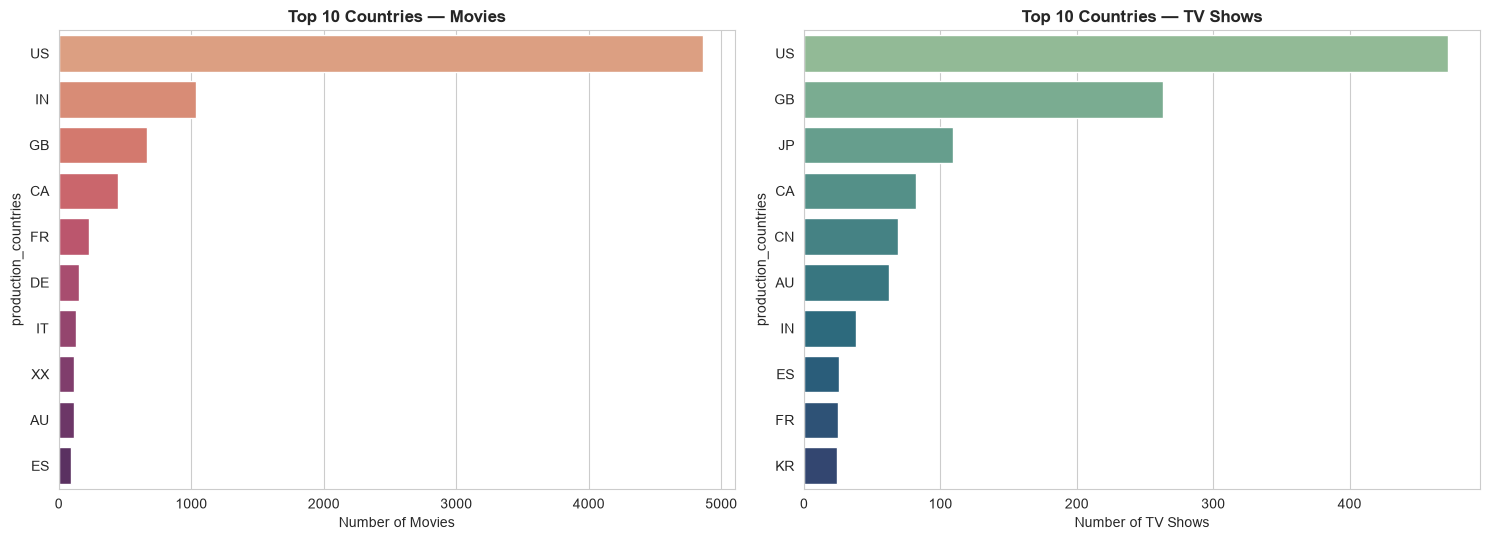

In [25]:
# Filtered by Movies and TV Shows separately
movies_by_country = country_exploded[country_exploded['type'] == 'MOVIE']['production_countries'].value_counts().head(10)
shows_by_country = country_exploded[country_exploded['type'] == 'SHOW']['production_countries'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sns.barplot(x=movies_by_country.values, y=movies_by_country.index, hue=movies_by_country.index,
            palette='flare', legend=False, ax=axes[0])
axes[0].set_title('Top 10 Countries — Movies', fontweight='bold')
axes[0].set_xlabel('Number of Movies')

sns.barplot(x=shows_by_country.values, y=shows_by_country.index, hue=shows_by_country.index,
            palette='crest', legend=False, ax=axes[1])
axes[1].set_title('Top 10 Countries — TV Shows', fontweight='bold')
axes[1].set_xlabel('Number of TV Shows')

plt.tight_layout()
plt.show()